In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import joblib

# Habilita o reload automático do nosso arquivo .py
%load_ext autoreload
%autoreload 2

from data_pipeline import extrair_telemetria_piloto

# Injeção dinâmica de dados!
ano_escolhido = 2024
gp_escolhido = 'Bahrain'
piloto_escolhido = 'VER'

print(f"Buscando dados dinâmicos: {piloto_escolhido} - {gp_escolhido} {ano_escolhido}...")
dados_modeloML = extrair_telemetria_piloto(ano_escolhido, gp_escolhido, piloto_escolhido)

print("\nMotor conectado! Dados prontos para separar em X e y.")

KeyboardInterrupt: 

In [ ]:
y = dados_modeloML['LapTime']
X = dados_modeloML.drop(columns=['LapTime'])

print("Tamanho do X (Features):", X.shape)
print("Tamanho do y (Target):", y.shape)

X.head()

Tamanho do X (Features): (52, 8)
Tamanho do y (Target): (52,)


,LapNumber,Stint,TyreLife,Compound_HARD,Compound_SOFT,Compound_MEDIUM,Compound_INTERMEDIATE,Compound_WET
1,2.0,1.0,5.0,0,1,0,0,0
2,3.0,1.0,6.0,0,1,0,0,0
3,4.0,1.0,7.0,0,1,0,0,0
4,5.0,1.0,8.0,0,1,0,0,0
5,6.0,1.0,9.0,0,1,0,0,0


In [ ]:
def treinar_modelo_adaboost(X, y):
    # y = dados_df['LapTime']
    # X = dados_df.drop(columns=['LapTime'])

    modelo = AdaBoostRegressor(random_state=42)
    modelo.fit(X, y)

    return modelo

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamanho do X_train:", X_train.shape)
print("Tamanho do X_test:", X_test.shape)
print("Tamanho do y_train:", y_train.shape)
print("Tamanho do y_test:", y_test.shape)

Tamanho do X_train: (41, 8)
Tamanho do X_test: (11, 8)
Tamanho do y_train: (41,)
Tamanho do y_test: (11,)


In [ ]:
modelo = treinar_modelo_adaboost(X_train, y_train)



#Aqui vemos q o adaboost criou uma sequencia de 50 arvores encadeadas, tentando corrigir os erros da anterior
#os atributos treinados foram o tyrelife q teve um percentual de importancia de 64%, lapnumber de 36%, stint 1% compound de 0%

In [ ]:
previsoes = modelo.predict(X_test)

print("Previsões:", previsoes[:5])  # Exibe as primeiras 5 previsões

Previsões: [95.48354545 94.48642857 95.184      97.03       94.53463636]


In [ ]:
print("Erro médio absoluto (MAE):", mean_absolute_error(y_test, previsoes))

Erro médio absoluto (MAE): 0.4776132936507942


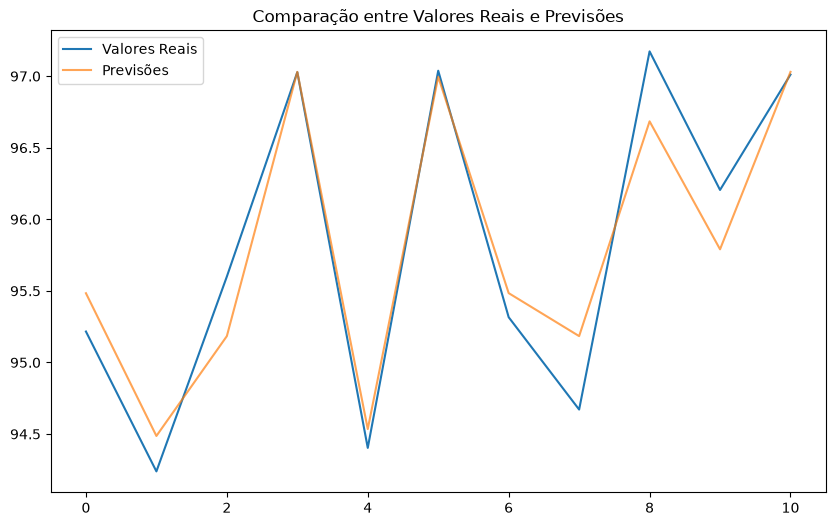

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.reset_index(drop=True), label='Valores Reais')
plt.plot(previsoes, label='Previsões', alpha=0.7)
plt.legend()
plt.title('Comparação entre Valores Reais e Previsões')
plt.show()